# CANSAT Duck2Dragon — Data Analysis

Reads `final_log.csv` — the **merged dual-LoRa** log written by the ground station
(`ground_station_monitor.py`). Two receivers (`port1`, `port2`) log in parallel; each
row is the best packet selected for a given timestamp, tagged with its `source` and
link quality (`rssi`, `snr`).

## CSV fields (28)
| # | Field | Unit | Source |
|---|-------|------|--------|
| 0 | time | ISO8601 | ground station clock |
| 1 | lat | deg | GPS |
| 2 | lon | deg | GPS |
| 3 | alt_gps | m | GPS |
| 4 | sats | count | GPS |
| 5 | millis | ms | ESP32 uptime |
| 6 | alt_baro | m | MS5611 |
| 7 | temp | °C | MS5611 |
| 8 | pressure | hPa | MS5611 |
| 9–11 | ax, ay, az | m/s² | BNO085 linear accel |
| 12–14 | gx, gy, gz | rad/s | BNO085 gyro |
| 15–18 | qw, qx, qy, qz | — | BNO085 quaternion |
| 19–21 | high_ax, high_ay, high_az | g | ADXL375 (±200g) |
| 22 | voltage | V | INA219 |
| 23 | current | mA | INA219 |
| 24 | watt | W | INA219 |
| 25 | source | port1/port2 | LoRa receiver |
| 26 | rssi | dBm | LoRa link |
| 27 | snr | dB | LoRa link |

> LoRa is lossy — some packets arrive corrupted. The loader drops physically
> impossible values (temp outside −20…100 °C, voltage outside 0…5 V, etc.) before analysis.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LOG_PATH = Path('rocket_log.csv')

# Merged ground-station log: has a header row, '# ...' comment lines, and
# link-quality columns (source, rssi, snr) appended by the receiver.
df = pd.read_csv(LOG_PATH, comment='#', skip_blank_lines=True)

# Numeric coercion for every sensor column (rssi/snr may be blank on some rows)
num_cols = [c for c in df.columns if c not in ('time', 'source')]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Wall-clock timestamp -> seconds since first packet (robust to millis rollover)
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df['time_s'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds()

raw_count = len(df)

# --- Drop physically impossible values from corrupted LoRa packets ---
df.loc[(df.temp < -20) | (df.temp > 100), 'temp'] = np.nan
df.loc[(df.pressure < 800) | (df.pressure > 1100), 'pressure'] = np.nan
df.loc[(df.voltage < 0) | (df.voltage > 5), 'voltage'] = np.nan
df.loc[(df.current < -2000) | (df.current > 2000), 'current'] = np.nan
df.loc[df.alt_baro.abs() > 5000, 'alt_baro'] = np.nan
df.loc[(df.alt_gps < -500) | (df.alt_gps > 10000), 'alt_gps'] = np.nan

print(f'Loaded {raw_count} rows from {LOG_PATH.name}')
print(f"Sources: {df['source'].value_counts().to_dict()}")
print(f"Time span: {df['time'].iloc[0]} -> {df['time'].iloc[-1]}")
df.head()

Loaded 74 rows from rocket_log.csv
Sources: {'port1': 53, 'port2': 21}
Time span: 2026-06-12 14:49:33 -> 2026-06-12 14:50:26


,time,lat,lon,alt_gps,sats,millis,alt_baro,temp,pressure,ax,...,high_ax,high_ay,high_az,voltage,current,watt,source,rssi,snr,time_s
0,2026-06-12 14:49:33,12.609127,100.941284,5.3,12,2264768,8.75,38.55,1012.20,0.2305,...,0.0,0.0,0.0,3.876,-98.5,-0.382,port2,-91,11.00,0.0
1,2026-06-12 14:49:34,12.609127,100.941284,5.3,12,2265454,9.08,38.56,1012.16,0.2305,...,0.0,0.0,0.0,3.880,-106.3,-0.412,port2,-91,11.50,1.0
2,2026-06-12 14:49:35,12.609127,100.941284,5.3,12,2266137,8.75,38.56,1012.20,0.2305,...,0.0,0.0,0.0,3.892,-103.9,-0.404,port2,-91,11.00,2.0
3,2026-06-12 14:49:35,12.609127,100.941284,5.3,12,2266820,9.08,38.56,1012.16,0.2305,...,0.0,0.0,0.0,3.888,-100.8,-0.392,port2,-91,11.50,2.0
4,2026-06-12 14:49:36,12.609143,100.941299,5.3,12,2267513,8.58,38.56,1012.22,0.2305,...,0.0,0.0,0.0,3.892,-105.9,-0.412,port2,-92,10.25,3.0


In [56]:
# Summary statistics
df.describe().round(3)

,time,lat,lon,alt_gps,sats,millis,alt_baro,temp,pressure,ax,...,qz,high_ax,high_ay,high_az,voltage,current,watt,rssi,snr,time_s
count,74,74.000,74.000,74.000,74.000,74.000,74.000,74.000,74.000,74.00,...,74.000,74.0,74.0,74.0,74.000,74.000,74.000,74.000,74.000,74.000
mean,2026-06-12 14:49:59.959459,12.608,100.941,48.864,10.703,2291447.365,103.846,37.217,1000.824,0.23,...,-0.715,0.0,0.0,0.0,3.839,-98.905,-0.380,-91.284,9.645,26.959
min,2026-06-12 14:49:33,12.606,100.940,5.300,0.000,2264768.000,8.080,34.400,977.900,0.23,...,-0.715,0.0,0.0,0.0,3.616,-110.200,-0.421,-105.000,-7.250,0.000
25%,2026-06-12 14:49:46.500000,12.607,100.941,5.300,12.000,2278216.500,35.905,35.788,997.170,0.23,...,-0.715,0.0,0.0,0.0,3.809,-101.175,-0.391,-93.750,9.562,13.500
50%,2026-06-12 14:50:00.500000,12.608,100.941,5.300,12.000,2292099.500,85.605,37.910,1003.010,0.23,...,-0.715,0.0,0.0,0.0,3.836,-98.350,-0.380,-91.000,10.750,27.500
75%,2026-06-12 14:50:13,12.609,100.941,100.900,12.000,2304703.000,129.392,38.580,1008.945,0.23,...,-0.715,0.0,0.0,0.0,3.888,-95.925,-0.366,-88.250,11.500,40.000
max,2026-06-12 14:50:26,12.609,100.941,126.100,12.000,2317467.000,298.560,38.620,1012.280,0.23,...,-0.715,0.0,0.0,0.0,3.904,-87.300,-0.319,-81.000,13.750,53.000
std,NaN,0.001,0.000,48.096,3.752,15655.547,90.004,1.532,10.675,0.00,...,0.000,0.0,0.0,0.0,0.056,4.326,0.018,5.068,3.331,15.673


In [57]:
# Data quality check
print('NaN count per column (after outlier removal):')
print(df.isna().sum())
print(f'\nGPS fix rows (sats > 0): {(df.sats > 0).sum()} / {len(df)}')
print(f'Baro valid rows: {df.alt_baro.notna().sum()} / {len(df)}')
print(f'Duration: {df.time_s.max():.1f} s ({df.time_s.max()/60:.1f} min)')
print(f'Mean packet rate: {len(df)/df.time_s.max():.2f} Hz')
print(f'\nPackets per receiver:')
for src, n in df['source'].value_counts().items():
    print(f'  {src}: {n} ({100*n/len(df):.1f}%)')

NaN count per column (after outlier removal):
time        0
lat         0
lon         0
alt_gps     0
sats        0
millis      0
alt_baro    0
temp        0
pressure    0
ax          0
ay          0
az          0
gx          0
gy          0
gz          0
qw          0
qx          0
qy          0
qz          0
high_ax     0
high_ay     0
high_az     0
voltage     0
current     0
watt        0
source      0
rssi        0
snr         0
time_s      0
dtype: int64

GPS fix rows (sats > 0): 66 / 74
Baro valid rows: 74 / 74
Duration: 53.0 s (0.9 min)
Mean packet rate: 1.40 Hz

Packets per receiver:
  port1: 53 (71.6%)
  port2: 21 (28.4%)


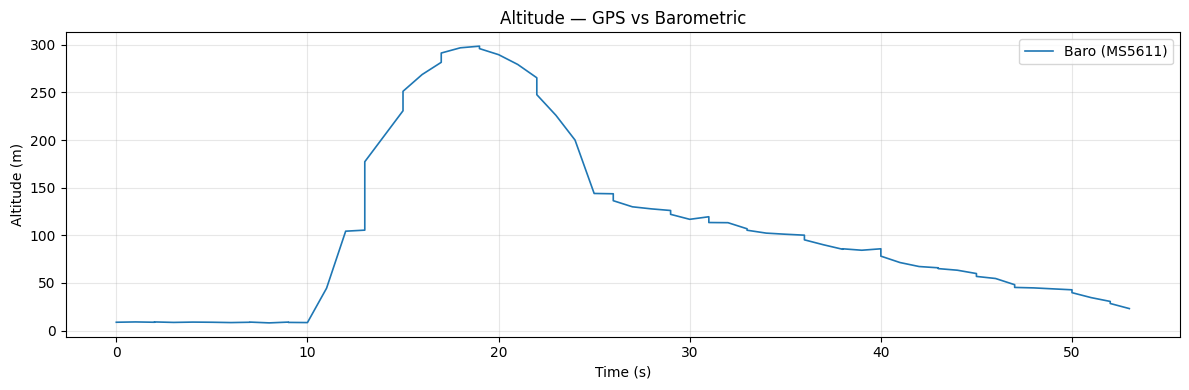

In [58]:
# Altitude: GPS vs Barometric
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.alt_baro, label='Baro (MS5611)', linewidth=1.2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Altitude — GPS vs Barometric')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

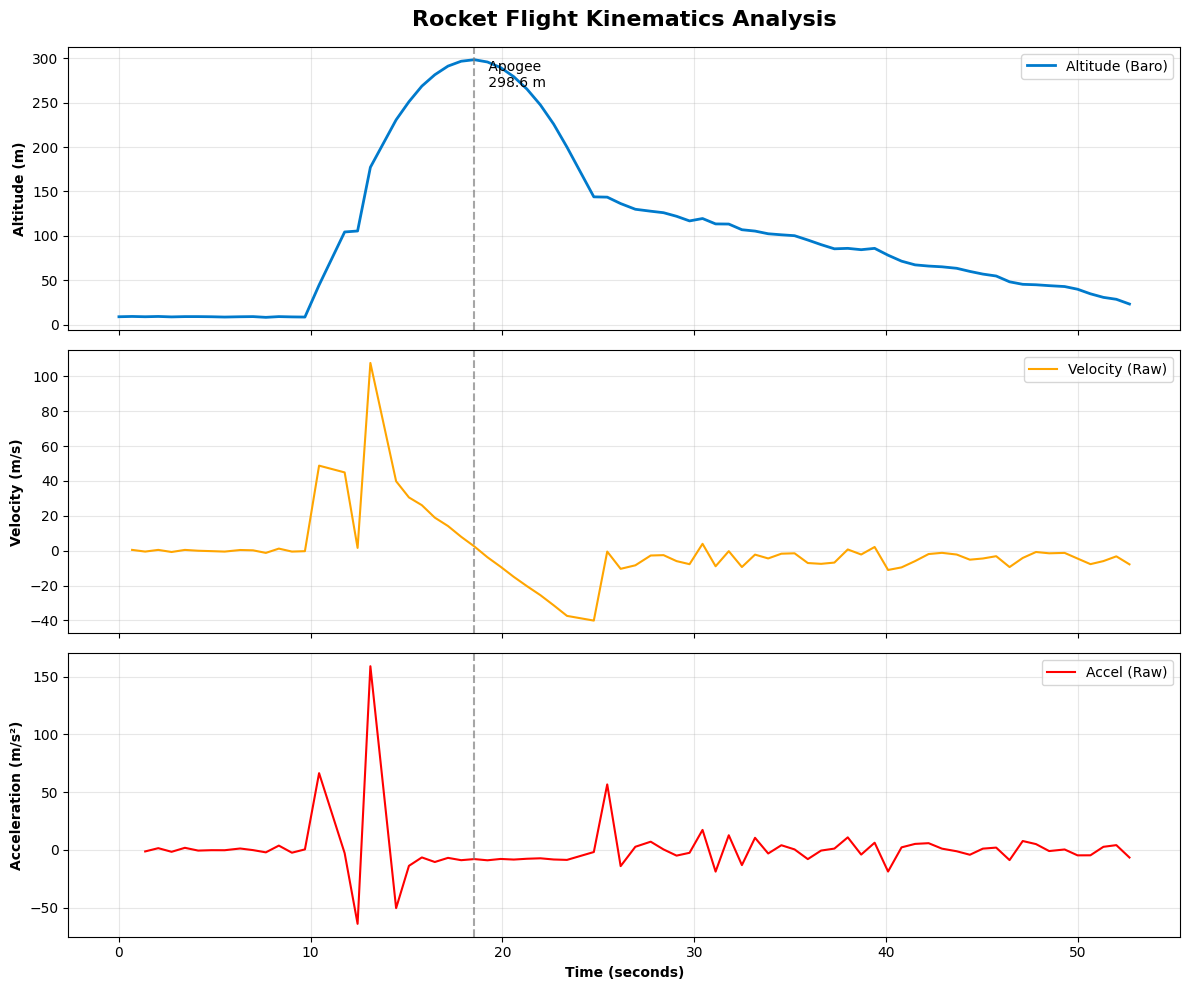

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. โหลดข้อมูล (ข้ามบรรทัด comment ที่ขึ้นต้นด้วย #)
df = pd.read_csv('rocket_log.csv', comment='#')

# 2. จัดการเรื่องเวลา (สำคัญมาก!)
# ใช้คอลัมน์ millis แปลงเป็นวินาที โดยให้จุดเริ่มต้นเป็น 0
df['time_s'] = (df['millis'] - df['millis'].iloc[0]) / 1000.0

# กรองแถวที่เวลาซ้ำกันทิ้งไป (เพื่อป้องกัน dt = 0)
df = df.drop_duplicates(subset=['time_s']).reset_index(drop=True)

# 3. คำนวณทางฟิสิกส์ (Numerical Differentiation)
df['dt'] = df['time_s'].diff()

# หาความเร็ว (v = dh/dt)
df['velocity_raw'] = df['alt_baro'].diff() / df['dt']

# หาความเร่ง (a = dv/dt)
df['accel_raw'] = df['velocity_raw'].diff() / df['dt']

# 4. การจัดการ Signal Noise
# ใช้ Rolling Mean แบบกำหนด min_periods=1 เพื่อไม่ให้ข้อมูลหัวท้ายหายไป
window = 5 
df['velocity_smooth'] = df['velocity_raw'].rolling(window=window, center=True, min_periods=1).mean()
df['accel_smooth'] = df['accel_raw'].rolling(window=window, center=True, min_periods=1).mean()

# 5. Plotting for Presentation
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
plt.subplots_adjust(hspace=0.25)

# --- Plot 1: Altitude ---
ax1.plot(df.time_s, df.alt_baro, color='#007acc', linewidth=2, label='Altitude (Baro)')
ax1.set_ylabel('Altitude (m)', fontweight='bold')
ax1.set_title('Rocket Flight Kinematics Analysis', fontsize=16, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# --- Plot 2: Velocity ---
ax2.plot(df.time_s, df.velocity_raw, color='orange', label='Velocity (Raw)')
ax2.set_ylabel('Velocity (m/s)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# --- Plot 3: Acceleration ---
ax3.plot(df.time_s, df.accel_raw, color='red', label='Accel (Raw)')
ax3.set_ylabel('Acceleration (m/s²)', fontweight='bold')
ax3.set_xlabel('Time (seconds)', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper right')

# ไฮไลท์จุด Apogee
apogee_idx = df['alt_baro'].idxmax()
apogee_time = df.loc[apogee_idx, 'time_s']
apogee_alt = df.loc[apogee_idx, 'alt_baro']

for ax in [ax1, ax2, ax3]:
    ax.axvline(apogee_time, color='gray', linestyle='--', alpha=0.7)
    if ax == ax1: 
        ax.text(apogee_time + 0.5, apogee_alt, f' Apogee\n {apogee_alt:.1f} m', verticalalignment='top')

plt.tight_layout()
plt.show()

In [60]:
df

,time,lat,lon,alt_gps,sats,millis,alt_baro,temp,pressure,ax,...,watt,source,rssi,snr,time_s,dt,velocity_raw,accel_raw,velocity_smooth,accel_smooth
0,2026-06-12T14:49:33,12.609127,100.941284,5.3,12,2264768,8.75,38.55,1012.20,0.2305,...,-0.382,port2,-91,11.00,0.000,NaN,NaN,NaN,-0.001056,-1.411731
1,2026-06-12T14:49:34,12.609127,100.941284,5.3,12,2265454,9.08,38.56,1012.16,0.2305,...,-0.412,port2,-91,11.50,0.686,0.686,0.481050,NaN,0.160350,0.001547
2,2026-06-12T14:49:35,12.609127,100.941284,5.3,12,2266137,8.75,38.56,1012.20,0.2305,...,-0.404,port2,-91,11.00,1.369,0.683,-0.483163,-1.411731,-0.060113,-0.578412
3,2026-06-12T14:49:35,12.609127,100.941284,5.3,12,2266820,9.08,38.56,1012.16,0.2305,...,-0.392,port2,-91,11.50,2.052,0.683,0.483163,1.414824,0.046874,-0.003478
4,2026-06-12T14:49:36,12.609143,100.941299,5.3,12,2267513,8.58,38.56,1012.22,0.2305,...,-0.412,port2,-92,10.25,2.745,0.693,-0.721501,-1.738331,-0.049336,-0.140014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,2026-06-12T14:50:23,12.607002,100.940567,57.7,12,2314758,39.79,34.61,1008.48,0.2305,...,-0.371,port1,-89,10.75,49.990,0.673,-4.472511,-4.804389,-4.162034,-1.557824
70,2026-06-12T14:50:24,12.607054,100.940559,57.7,12,2315432,34.61,34.54,1009.10,0.2305,...,-0.364,port1,-85,11.75,50.664,0.674,-7.685460,-4.766986,-4.510537,-0.531859
71,2026-06-12T14:50:25,12.607054,100.940559,57.7,12,2316107,30.60,34.48,1009.58,0.2305,...,-0.359,port1,-85,12.00,51.339,0.675,-5.940741,2.584769,-5.821829,-1.927101
72,2026-06-12T14:50:25,12.607088,100.940544,48.9,12,2316782,28.43,34.43,1009.84,0.2305,...,-0.381,port2,-92,10.75,52.014,0.675,-3.214815,4.038409,-6.159159,-1.207779


In [61]:
df.to_csv('final_log_processed_3.csv', index=False)

In [62]:
df.tail(10)

,time,lat,lon,alt_gps,sats,millis,alt_baro,temp,pressure,ax,...,watt,source,rssi,snr,time_s,dt,velocity_raw,accel_raw,velocity_smooth,accel_smooth
64,2026-06-12T14:50:20,12.606874,100.940559,76.2,12,2311214,48.15,35.01,1007.48,0.2305,...,-0.361,port1,-87,11.50,46.446,0.698,-9.355301,-8.923352,-4.357465,1.302346
65,2026-06-12T14:50:20,12.606874,100.940559,76.2,12,2311901,45.31,34.92,1007.82,0.2305,...,-0.362,port1,-90,10.25,47.133,0.687,-4.133916,7.600270,-3.762382,0.884837
66,2026-06-12T14:50:21,12.606941,100.940536,67.2,12,2312592,44.81,34.82,1007.88,0.2305,...,-0.371,port1,-97,5.75,47.824,0.691,-0.723589,4.935350,-3.384853,0.561950
67,2026-06-12T14:50:22,12.606941,100.940536,67.2,12,2313278,43.80,34.74,1008.00,0.2305,...,-0.382,port1,-97,6.25,48.510,0.686,-1.472303,-1.091420,-2.408295,1.385743
68,2026-06-12T14:50:23,12.606941,100.940536,67.2,12,2314085,42.80,34.67,1008.12,0.2305,...,-0.360,port1,-86,11.00,49.317,0.807,-1.239157,0.288904,-3.118604,-1.087708
69,2026-06-12T14:50:23,12.607002,100.940567,57.7,12,2314758,39.79,34.61,1008.48,0.2305,...,-0.371,port1,-89,10.75,49.990,0.673,-4.472511,-4.804389,-4.162034,-1.557824
70,2026-06-12T14:50:24,12.607054,100.940559,57.7,12,2315432,34.61,34.54,1009.10,0.2305,...,-0.364,port1,-85,11.75,50.664,0.674,-7.685460,-4.766986,-4.510537,-0.531859
71,2026-06-12T14:50:25,12.607054,100.940559,57.7,12,2316107,30.60,34.48,1009.58,0.2305,...,-0.359,port1,-85,12.00,51.339,0.675,-5.940741,2.584769,-5.821829,-1.927101
72,2026-06-12T14:50:25,12.607088,100.940544,48.9,12,2316782,28.43,34.43,1009.84,0.2305,...,-0.381,port2,-92,10.75,52.014,0.675,-3.214815,4.038409,-6.159159,-1.207779
73,2026-06-12T14:50:26,12.607088,100.940544,48.9,12,2317467,23.09,34.40,1010.48,0.2305,...,-0.381,port2,-104,-1.75,52.699,0.685,-7.795620,-6.687307,-5.650392,-0.021377


In [63]:
df

,time,lat,lon,alt_gps,sats,millis,alt_baro,temp,pressure,ax,...,watt,source,rssi,snr,time_s,dt,velocity_raw,accel_raw,velocity_smooth,accel_smooth
0,2026-06-12T14:49:33,12.609127,100.941284,5.3,12,2264768,8.75,38.55,1012.20,0.2305,...,-0.382,port2,-91,11.00,0.000,NaN,NaN,NaN,-0.001056,-1.411731
1,2026-06-12T14:49:34,12.609127,100.941284,5.3,12,2265454,9.08,38.56,1012.16,0.2305,...,-0.412,port2,-91,11.50,0.686,0.686,0.481050,NaN,0.160350,0.001547
2,2026-06-12T14:49:35,12.609127,100.941284,5.3,12,2266137,8.75,38.56,1012.20,0.2305,...,-0.404,port2,-91,11.00,1.369,0.683,-0.483163,-1.411731,-0.060113,-0.578412
3,2026-06-12T14:49:35,12.609127,100.941284,5.3,12,2266820,9.08,38.56,1012.16,0.2305,...,-0.392,port2,-91,11.50,2.052,0.683,0.483163,1.414824,0.046874,-0.003478
4,2026-06-12T14:49:36,12.609143,100.941299,5.3,12,2267513,8.58,38.56,1012.22,0.2305,...,-0.412,port2,-92,10.25,2.745,0.693,-0.721501,-1.738331,-0.049336,-0.140014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,2026-06-12T14:50:23,12.607002,100.940567,57.7,12,2314758,39.79,34.61,1008.48,0.2305,...,-0.371,port1,-89,10.75,49.990,0.673,-4.472511,-4.804389,-4.162034,-1.557824
70,2026-06-12T14:50:24,12.607054,100.940559,57.7,12,2315432,34.61,34.54,1009.10,0.2305,...,-0.364,port1,-85,11.75,50.664,0.674,-7.685460,-4.766986,-4.510537,-0.531859
71,2026-06-12T14:50:25,12.607054,100.940559,57.7,12,2316107,30.60,34.48,1009.58,0.2305,...,-0.359,port1,-85,12.00,51.339,0.675,-5.940741,2.584769,-5.821829,-1.927101
72,2026-06-12T14:50:25,12.607088,100.940544,48.9,12,2316782,28.43,34.43,1009.84,0.2305,...,-0.381,port2,-92,10.75,52.014,0.675,-3.214815,4.038409,-6.159159,-1.207779


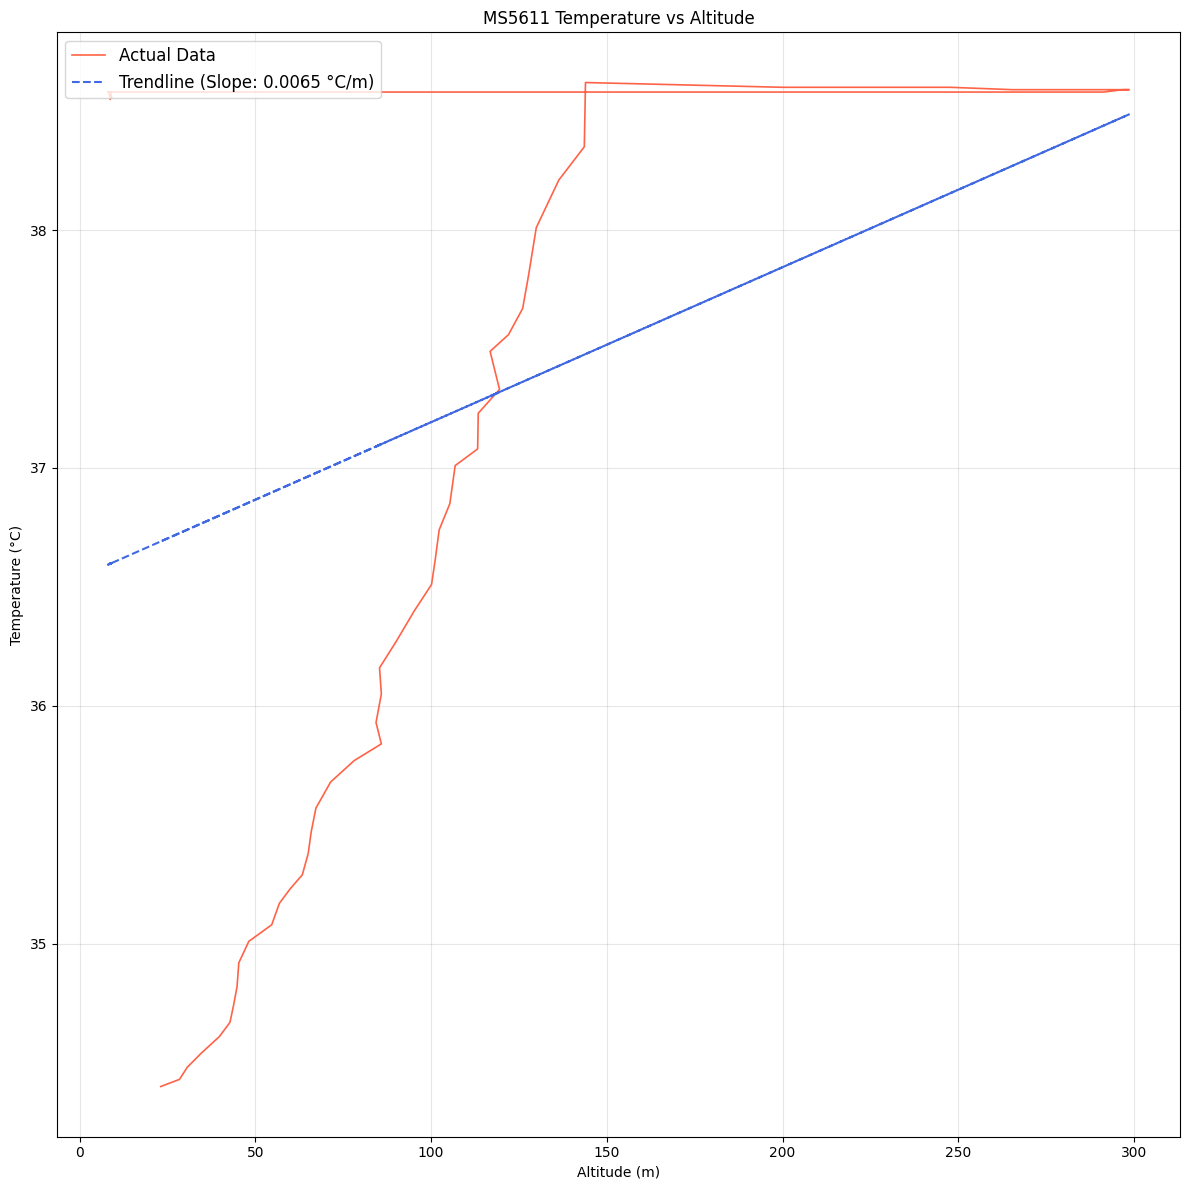

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# สร้างกราฟขนาด 12x12
fig, ax1 = plt.subplots(1, 1, figsize=(12, 12), sharex=True)

# 1. พลอตเส้นข้อมูลเดิม
ax1.plot(df.alt_baro, df.temp, color='tomato', linewidth=1.2, label='Actual Data')

# 2. คำนวณความชัน (m) และจุดตัดแกน (c) สำหรับสมการเส้นตรงเชิงเส้น (Degree 1)
# ค่าที่ได้จะเป็นอาเรย์ [ความชัน, จุดตัดแกน Y]
m, c = np.polyfit(df.alt_baro, df.temp, 1)

# 3. สร้างข้อมูลแกน Y สำหรับเส้นความชัน
trendline = m * df.alt_baro + c

# 4. พลอตเส้นความชัน (Trendline) ลงบนกราฟ
# ใช้เส้นประ (linestyle='--') เพื่อให้แยกจากข้อมูลจริงได้ชัดเจน
ax1.plot(df.alt_baro, trendline, color='royalblue', linestyle='--', linewidth=1.5, 
         label=f'Trendline (Slope: {m:.4f} °C/m)')

# ตั้งค่า Label และ Title
ax1.set_ylabel('Temperature (°C)')
ax1.set_xlabel('Altitude (m)')
ax1.set_title('MS5611 Temperature vs Altitude')

# เปิดใช้งาน Grid และ Legend
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=12) # แสดงกล่องข้อความอธิบายกราฟ

plt.tight_layout()
plt.show()

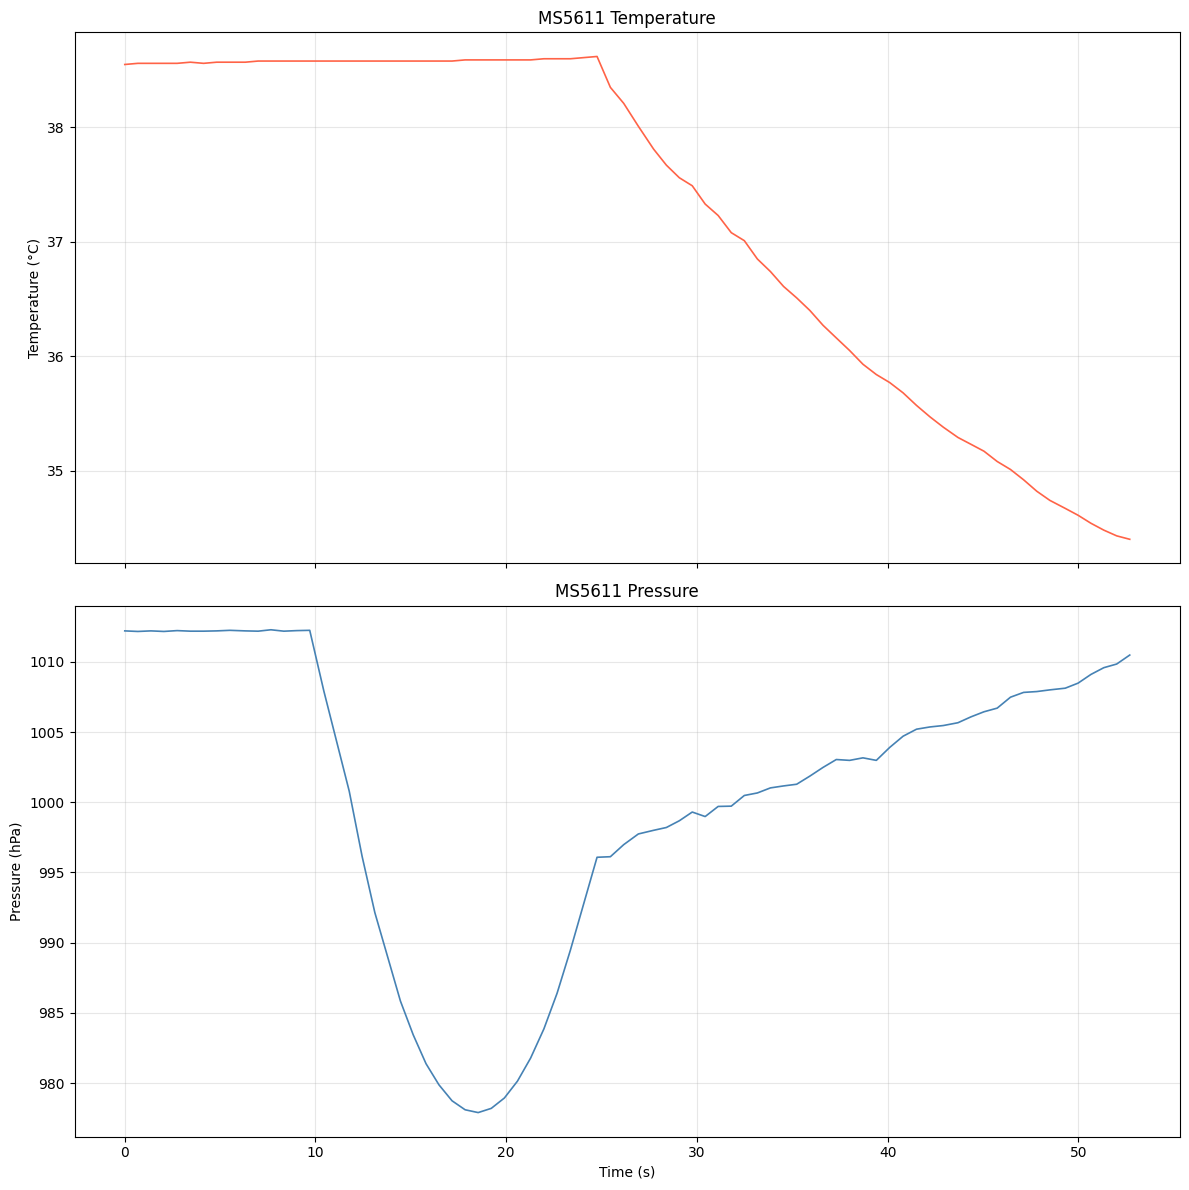

In [65]:
# Temperature & Pressure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
ax1.plot(df.time_s, df.temp, color='tomato', linewidth=1.2)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('MS5611 Temperature')
ax1.grid(True, alpha=0.3)
ax2.plot(df.time_s, df.pressure, color='steelblue', linewidth=1.2)
ax2.set_ylabel('Pressure (hPa)')
ax2.set_xlabel('Time (s)')
ax2.set_title('MS5611 Pressure')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

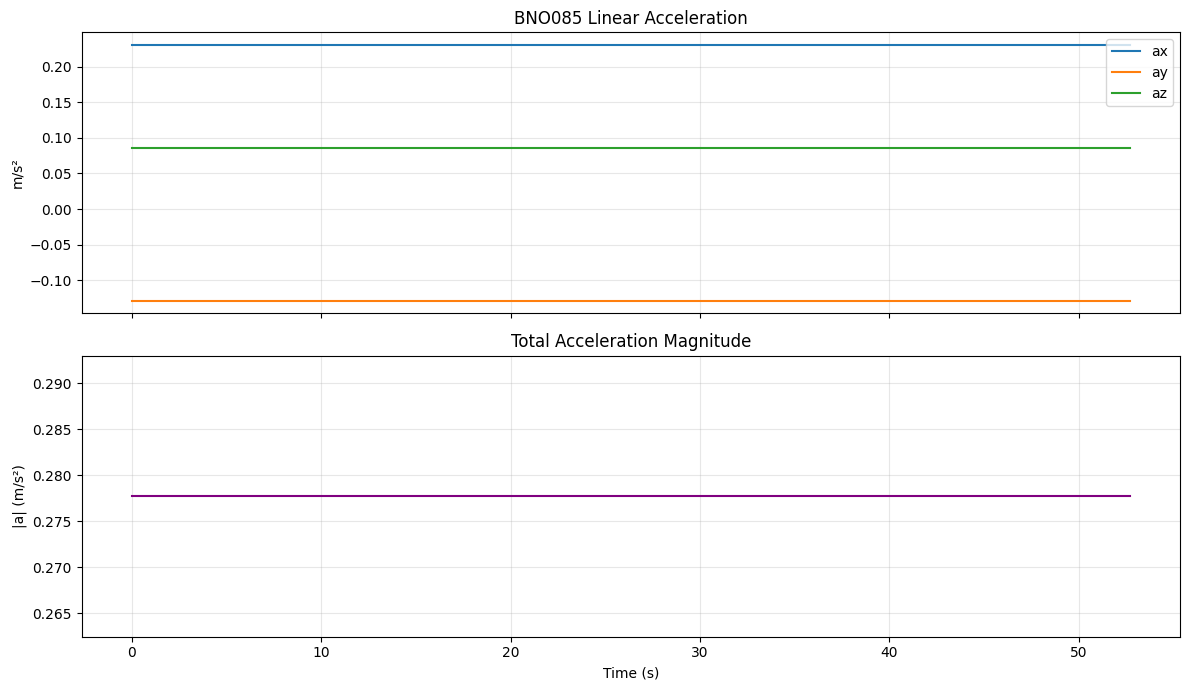

In [66]:
# BNO085 Linear Acceleration
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df.time_s, df.ax, label='ax')
axes[0].plot(df.time_s, df.ay, label='ay')
axes[0].plot(df.time_s, df.az, label='az')
axes[0].set_ylabel('m/s²')
axes[0].set_title('BNO085 Linear Acceleration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

df['accel_mag'] = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)
axes[1].plot(df.time_s, df.accel_mag, color='purple')
axes[1].set_ylabel('|a| (m/s²)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Total Acceleration Magnitude')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

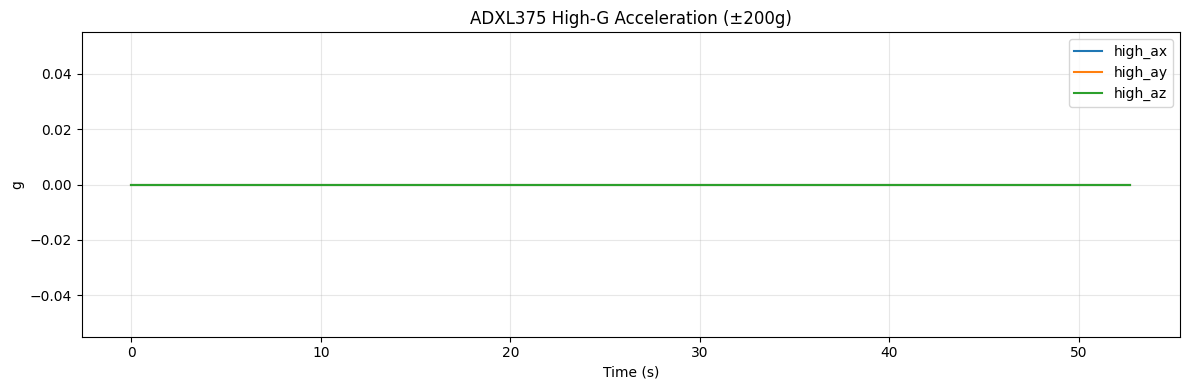

In [67]:
# ADXL375 High-G
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.high_ax, label='high_ax')
ax.plot(df.time_s, df.high_ay, label='high_ay')
ax.plot(df.time_s, df.high_az, label='high_az')
ax.set_xlabel('Time (s)')
ax.set_ylabel('g')
ax.set_title('ADXL375 High-G Acceleration (±200g)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

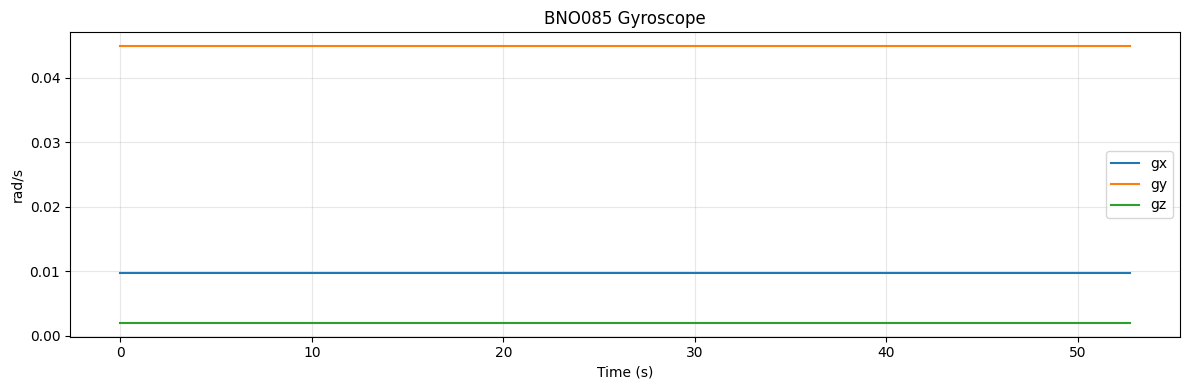

In [68]:
# BNO085 Gyroscope
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.gx, label='gx')
ax.plot(df.time_s, df.gy, label='gy')
ax.plot(df.time_s, df.gz, label='gz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('rad/s')
ax.set_title('BNO085 Gyroscope')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
df.value_counts()

time                 lat        lon         alt_gps  sats  millis   alt_baro  temp   pressure  ax      ay       az      gx      gy      gz     qw      qx      qy       qz       high_ax  high_ay  high_az  voltage  current  watt    source  rssi  snr     time_s  dt     velocity_raw  accel_raw  velocity_smooth  accel_smooth  accel_mag
2026-06-12T14:49:35  12.609127  100.941284  5.3      12    2266137  8.75      38.56  1012.20   0.2305  -0.1289  0.0859  0.0098  0.0449  0.002  0.6993  0.0096  -0.0036  -0.7148  0.0      0.0      0.0      3.892    -103.9   -0.404  port2   -91    11.00  1.369   0.683  -0.483163     -1.411731  -0.060113        -0.578412     0.277713     1
                                                           2266820  9.08      38.56  1012.16   0.2305  -0.1289  0.0859  0.0098  0.0449  0.002  0.6993  0.0096  -0.0036  -0.7148  0.0      0.0      0.0      3.888    -100.8   -0.392  port2   -91    11.50  2.052   0.683   0.483163      1.414824   0.046874        -0.003478     0.2777

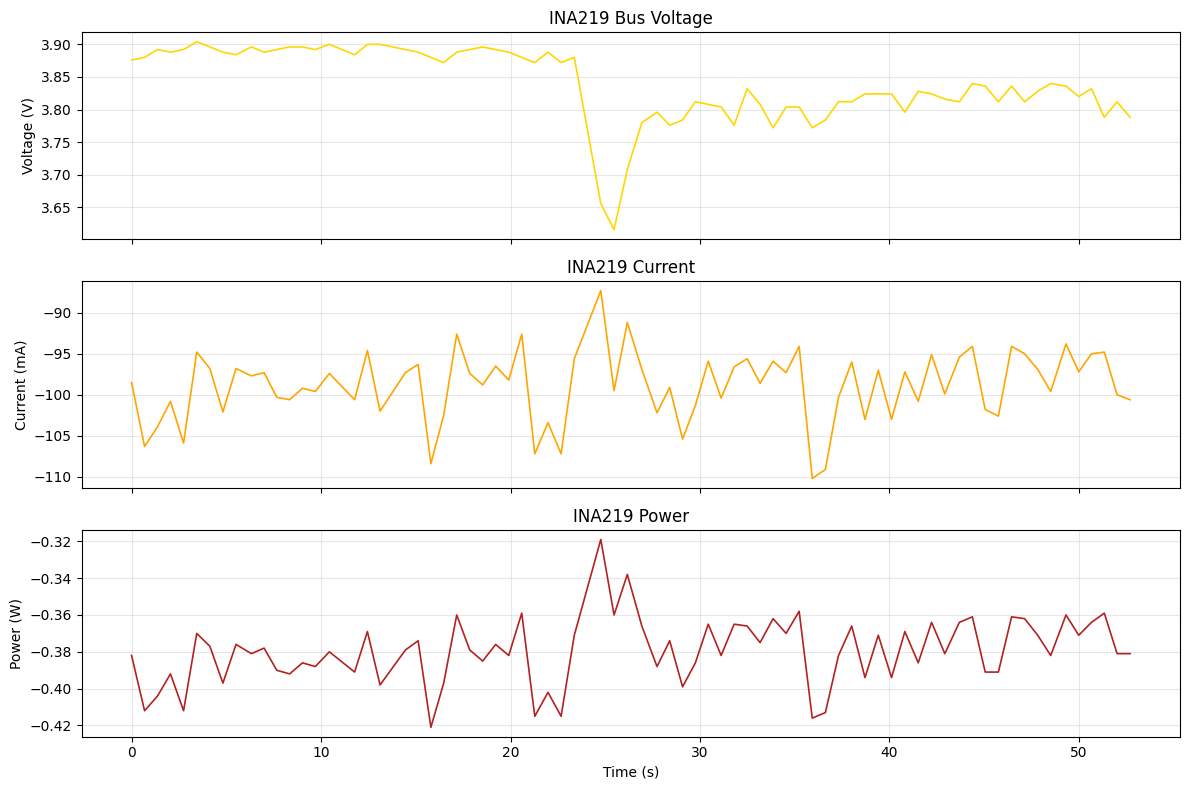

Avg voltage: 3.839 V  (min 3.616, max 3.904)
Avg current: -98.9 mA
Avg power:   -0.380 W


In [70]:
# Power: Voltage, Current & Watt
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax1.plot(df.time_s, df.voltage, color='gold', linewidth=1.2)
ax1.set_ylabel('Voltage (V)')
ax1.set_title('INA219 Bus Voltage')
ax1.grid(True, alpha=0.3)
ax2.plot(df.time_s, df.current, color='orange', linewidth=1.2)
ax2.set_ylabel('Current (mA)')
ax2.set_title('INA219 Current')
ax2.grid(True, alpha=0.3)
ax3.plot(df.time_s, df.watt, color='firebrick', linewidth=1.2)
ax3.set_ylabel('Power (W)')
ax3.set_xlabel('Time (s)')
ax3.set_title('INA219 Power')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Avg voltage: {df.voltage.mean():.3f} V  (min {df.voltage.min():.3f}, max {df.voltage.max():.3f})')
print(f'Avg current: {df.current.mean():.1f} mA')
print(f'Avg power:   {df.watt.mean():.3f} W')

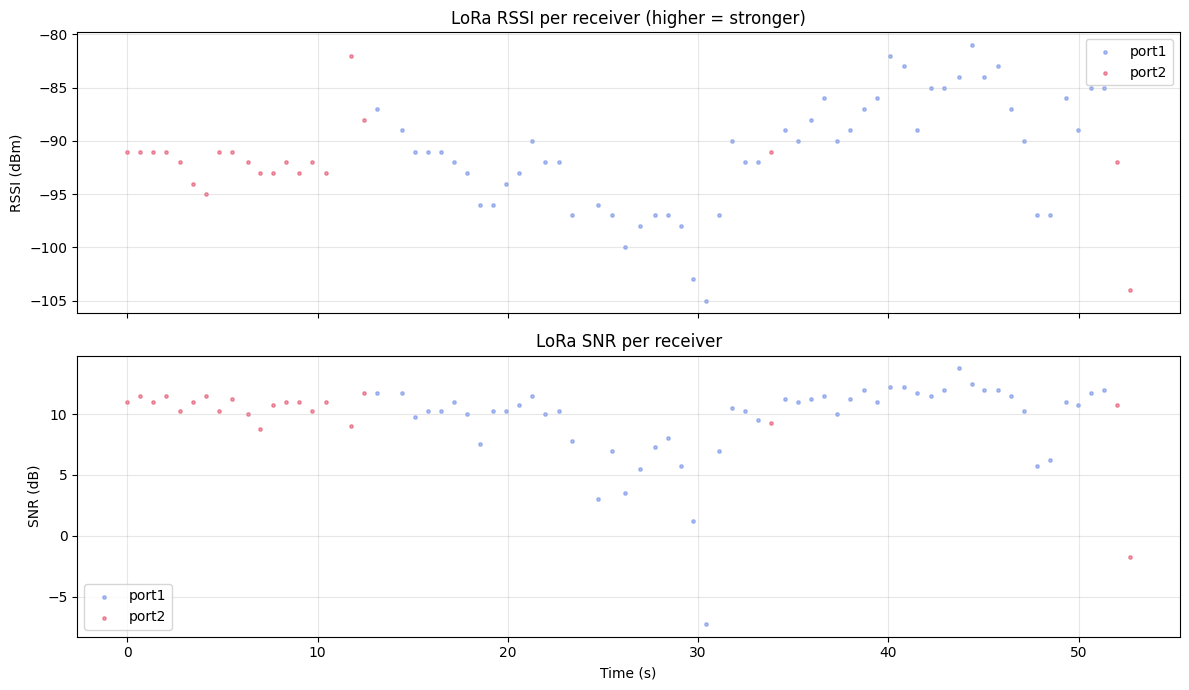

Link quality summary:
  port1: RSSI mean=-91.0 dBm (min -105), SNR mean=9.5 dB
  port2: RSSI mean=-92.0 dBm (min -104), SNR mean=10.0 dB


In [71]:
# LoRa Link Quality — RSSI & SNR per receiver
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
colors = {'port1': 'royalblue', 'port2': 'crimson'}
for src, g in df.groupby('source'):
    c = colors.get(src, 'gray')
    ax1.scatter(g.time_s, g.rssi, s=6, alpha=0.4, color=c, label=src)
    ax2.scatter(g.time_s, g.snr,  s=6, alpha=0.4, color=c, label=src)
ax1.set_ylabel('RSSI (dBm)')
ax1.set_title('LoRa RSSI per receiver (higher = stronger)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.set_ylabel('SNR (dB)')
ax2.set_xlabel('Time (s)')
ax2.set_title('LoRa SNR per receiver')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Link quality summary:')
for src, g in df.groupby('source'):
    print(f"  {src}: RSSI mean={g.rssi.mean():.1f} dBm (min {g.rssi.min():.0f}), "
          f"SNR mean={g.snr.mean():.1f} dB")

In [72]:
gps_valid.value_counts()

NameError: name 'gps_valid' is not defined

In [ ]:
import plotly.express as px

gps_valid = df[(df.sats > 0) & df.lat.notna() & df.lon.notna()
               & (df.lat != 0) & (df.lon != 0)]

if len(gps_valid) > 0:
    # 1. เปลี่ยนจาก px.scatter_map เป็น px.line_map
    fig = px.line_map(
        gps_valid,
        lat='lat',
        lon='lon',
        zoom=14,
        height=600,
        title=f'GPS Track ({len(gps_valid)} fixes)',
        map_style='open-street-map',
    )
    fig.update_layout(margin={'r': 0, 't': 30, 'l': 0, 'b': 0})
    fig.show()
else:
    print('No valid GPS fix in log.')

Apogee (baro): 298.56 m at t=10.0 s


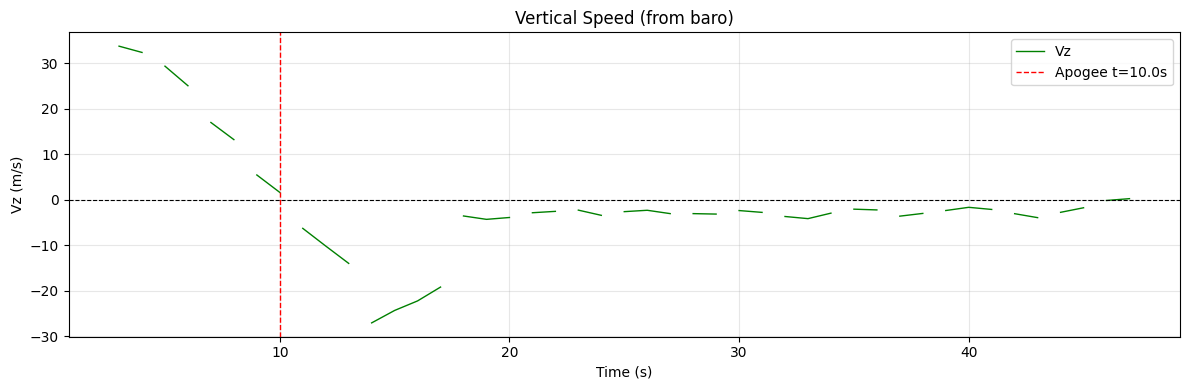

In [ ]:
# Apogee detection + vertical speed
idx_apogee = df.alt_baro.idxmax()
apogee_alt = df.alt_baro[idx_apogee]
apogee_t   = df.time_s[idx_apogee]
print(f'Apogee (baro): {apogee_alt:.2f} m at t={apogee_t:.1f} s')

df['alt_smooth'] = df.alt_baro.rolling(5, center=True).mean()
df['vz'] = df.alt_smooth.diff() / df.time_s.diff()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.vz, color='green', linewidth=1.0, label='Vz')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(apogee_t, color='red', linewidth=1.0, linestyle='--', label=f'Apogee t={apogee_t:.1f}s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Vz (m/s)')
ax.set_title('Vertical Speed (from baro)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Export cleaned CSV
out_path = Path('log_clean.csv')
df.to_csv(out_path, index=False)
print(f'Saved {len(df)} rows to {out_path}')

Saved 70 rows to log_clean.csv
